Familiarizing with the Dataset

Steps for Initial Data Analysis (EDA)⏬


Obtain the overall structure of the data:


In [19]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path='/content/drive/MyDrive/colab notebooke/Boston Houses.xlsx'
data=pd.read_excel(file_path)

print("data info: ")
print(data.info())

print("data describe: ")
print(data.describe())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     480 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      479 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        486 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     452 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB
None
data describe: 
             CRIM          ZN       INDUS        CHAS         NOX        

Identify missing values in the columns and their proportions:

In [ ]:
missing_values=data.isnull().sum()
missing_proportions=missing_values/len(data)

print(missing_values)
print(missing_proportions)


CRIM        0
ZN          0
INDUS       0
CHAS       26
NOX         0
RM          0
AGE         0
DIS        27
RAD         0
TAX         0
PTRATIO     0
B          20
LSTAT       0
MEDV       54
dtype: int64
CRIM       0.000000
ZN         0.000000
INDUS      0.000000
CHAS       0.051383
NOX        0.000000
RM         0.000000
AGE        0.000000
DIS        0.053360
RAD        0.000000
TAX        0.000000
PTRATIO    0.000000
B          0.039526
LSTAT      0.000000
MEDV       0.106719
dtype: float64


number of unique values for each feature:

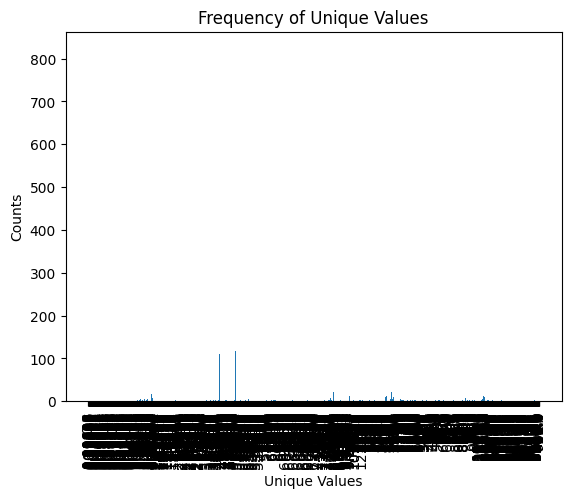

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = np.array(data)

data_flattened = data.flatten()

number of unique values for each feature:


[ ]


unique_values = np.unique(data_flattened)
counts = [np.sum(data_flattened == value) for value in unique_values]

plt.bar(range(len(unique_values)), counts)
plt.xticks(range(len(unique_values)), unique_values, rotation=90)
plt.xlabel('Unique Values')
plt.ylabel('Counts')
plt.title('Frequency of Unique Values')
plt.show()


 Correlation matrix:

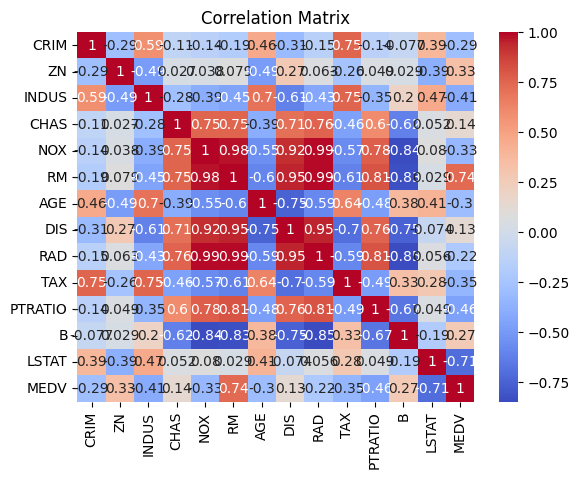

In [ ]:
import seaborn as sns

correlation_matrix=data.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


Section 2: Data Preprocessing⏬

create MEDVC:

In [10]:
#first we calculated "mean" and "std" to divide prices into 3 parts (low,medium,high) then made a new column and added it to dataframe
mean_medv=data['MEDV'].mean()
std_medv=data['MEDV'].std()

data['MEDVC']=pd.cut(data['MEDV'],bins=[data['MEDV'].min(),mean_medv-std_medv,mean_medv+std_medv,data['MEDV'].max()],labels=['Low','Medium','High'])

print(data['MEDVC'])

0      NaN
1      NaN
2      Low
3      NaN
4      NaN
      ... 
501    NaN
502    NaN
503    NaN
504    NaN
505    NaN
Name: MEDVC, Length: 506, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']


Handling Missing Values:

In [9]:
#here is the removal of raw with missing value method:

data = pd.DataFrame(data) # Convert the data to a DataFrame to clean it

data_cleaned = data.dropna(axis=0)

Feature Removal:

In [5]:
from google.colab import drive
import pandas as pd
import numpy as np
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/colab notebooke/Boston Houses.xlsx'
data=pd.read_excel(file_path)
data = pd.DataFrame(data) # Convert the data to a DataFrame to clean it

# keep the 'MEDV' column
data_cleaned = data.dropna(subset=['MEDV'])

# we can use correlation matrix to remove unnessecery feature:

# Calculate the correlation matrix
correlation_with_target = data_cleaned.corr()['MEDV'].sort_values(ascending=False)
print(correlation_with_target)

Mounted at /content/drive
MEDV       1.000000
RM         0.740181
ZN         0.331570
B          0.269605
CHAS       0.136668
DIS        0.129355
RAD       -0.217902
CRIM      -0.286245
AGE       -0.299893
NOX       -0.332778
TAX       -0.345898
INDUS     -0.411915
PTRATIO   -0.461214
LSTAT     -0.706255
Name: MEDV, dtype: float64


Categorical vs. Numerical Features:

although there is 0 , and 1 in the dataset are recognized as binary attributes and we should put them in categorical feature.

In [ ]:
⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰


Normalization and Standardization:

Normalization::rescales the data to a fixed range (usually [0, 1]), making all features equal in magnitude but not necessarily normal in distribution.


Standardization::centers the data by removing the mean and scales it by the standard deviation, making the distribution of features standard normal (mean = 0, standard deviation = 1).



in this project, as you can see we have different value with different units

 so  it seems that normalization is better choice  to make our model easier to undrestand

In [6]:
#to normalization we should use scikit-learn library:

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
data_normalized=scaler.fit_transform(data_cleaned)



Preprocessing Categorical Features:


 ⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰




Data Split:

Common Methods for Splitting Data

1-K-Fold Cross-Validation
2-Stratified Split
3-Time Series Split
& 4-Random Split: dataset is randomly divided into training, validation, and test sets. This method is simple and widely used.


In [8]:
#"Here, to split the data, we first divide it into 60% for training and 40% for testing and validation.
#Then, we further divide that 40% into two equal parts of 20% each for validation and testing."

from sklearn.model_selection import train_test_split

x=data_cleaned.drop('MEDV',axis=1)
y=data_cleaned['MEDV']

x_train, x_temp, y_train, y_temp = train_test_split(x ,y , test_size=0.4, random_state=19)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=19)


Section 3: Model Training, Evaluation, and Tuning⏬

In [ ]:

from sklearn.tree import DecisionTreeRegressor # Import regressor instead of classifier
from sklearn.naive_bayes import GaussianNB

# Decision tree regressor model
dt = DecisionTreeRegressor(random_state=19) # Change to DecisionTreeRegressor
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

# Naive Bayes model (may need adjustment for continuous target)
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)

DONT KNOW HOW TO FIX IT⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰⏰